<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\g'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_2495/3226836179.py:17: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Sinyal Pertama $x_1[n] = \sin(0.5\pi n)$')
/tmp/ipykernel_2495/3226836179.py:25: SyntaxWarning: invalid escape sequence '\g'
  plt.title('Sinyal Kedua $x_2[n]$ (Unit Step $n \geq 5$)')


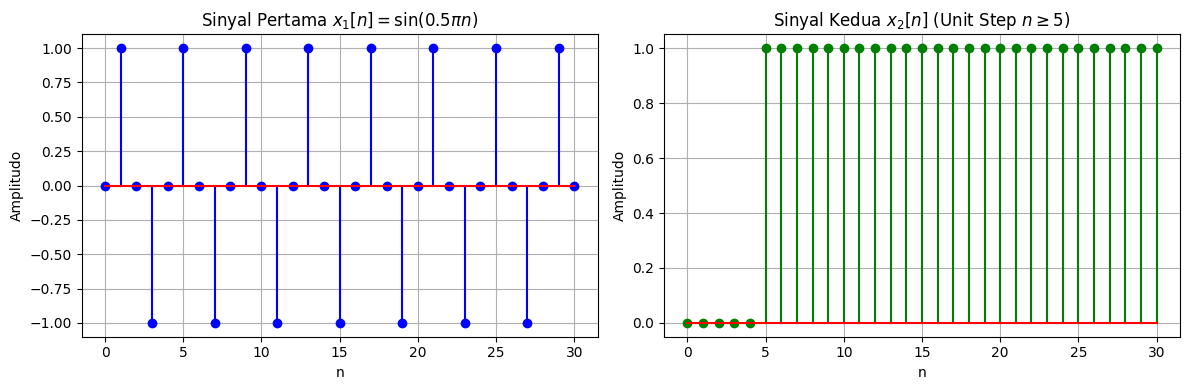

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Tentukan rentang n (0 sampai 30)
n = np.arange(0, 31)

# 2. Bangkitkan Sinyal Pertama: x1[n] = sin(0.5 * pi * n)
x1 = np.sin(0.5 * np.pi * n)

# 3. Bangkitkan Sinyal Kedua: x2[n] = unit step (n >= 5)
x2 = np.where(n >= 5, 1.0, 0.0)

# 4. Plot Sinyal x1[n]
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.stem(n, x1, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title('Sinyal Pertama $x_1[n] = \sin(0.5\pi n)$')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.grid(True)

# 5. Plot Sinyal x2[n]
plt.subplot(1, 2, 2)
plt.stem(n, x2, linefmt='g-', markerfmt='go', basefmt='r-')
plt.title('Sinyal Kedua $x_2[n]$ (Unit Step $n \geq 5$)')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.grid(True)

plt.tight_layout()
plt.show()

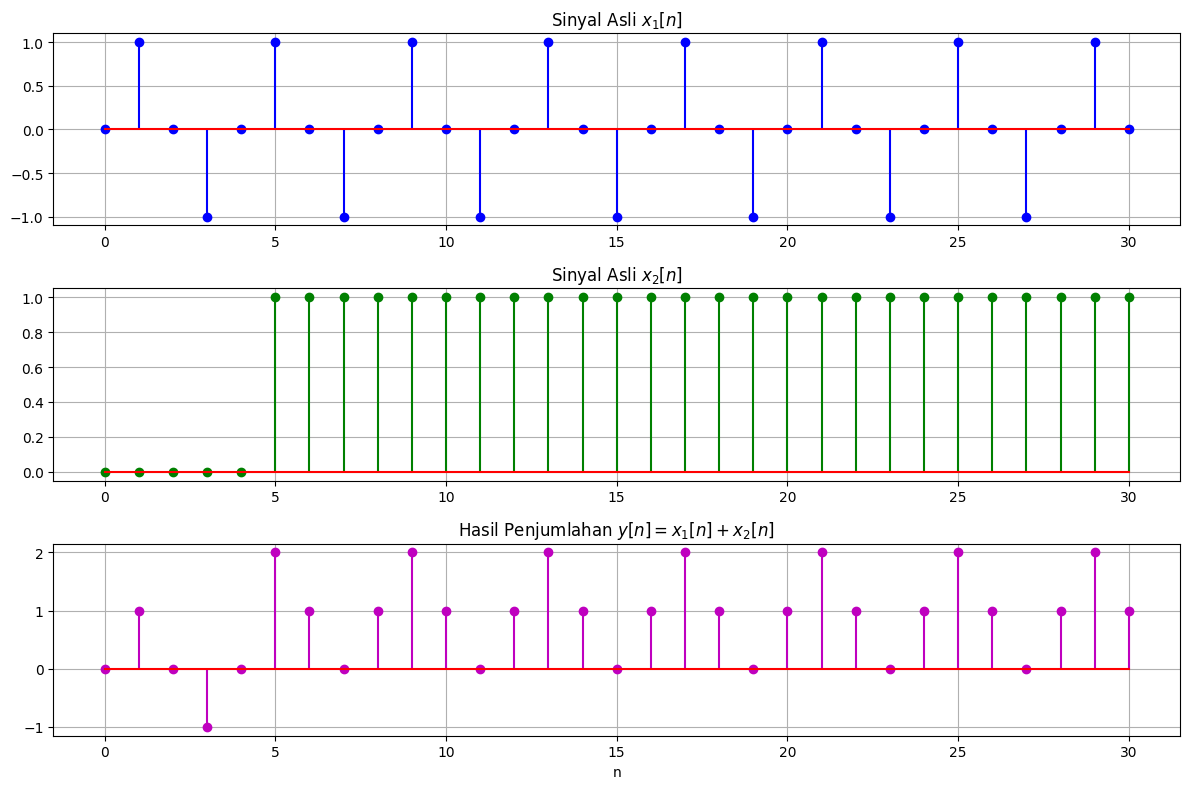

In [2]:
# Operasi Penjumlahan
y_add = x1 + x2

# Plot Perbandingan
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.stem(n, x1, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title('Sinyal Asli $x_1[n]$')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.stem(n, x2, linefmt='g-', markerfmt='go', basefmt='r-')
plt.title('Sinyal Asli $x_2[n]$')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.stem(n, y_add, linefmt='m-', markerfmt='mo', basefmt='r-')
plt.title('Hasil Penjumlahan $y[n] = x_1[n] + x_2[n]$')
plt.xlabel('n')
plt.grid(True)

plt.tight_layout()
plt.show()

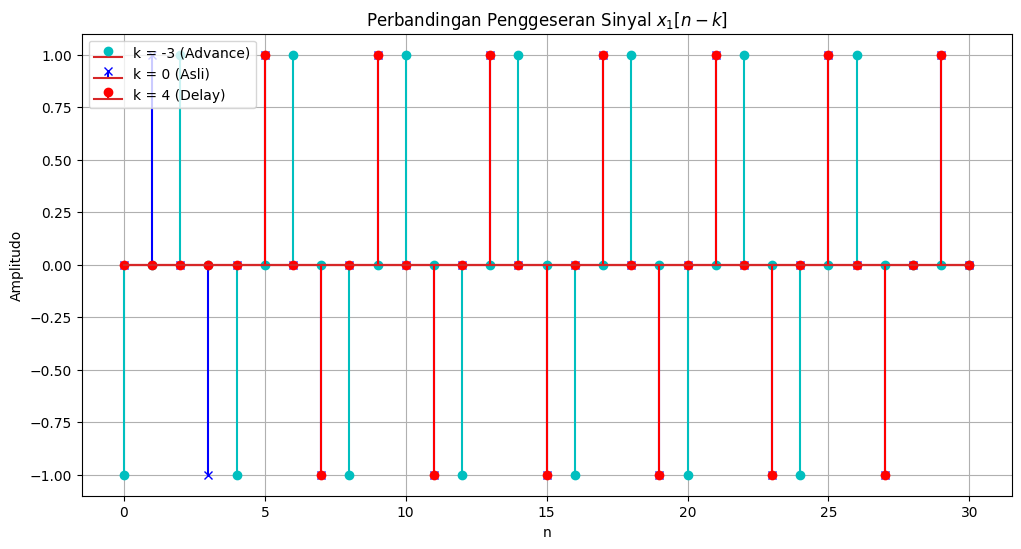

In [3]:
def shift_signal(signal, k):
    # Menggeser sinyal dengan teknik padding nol di ujungnya
    if k > 0:
        return np.concatenate((np.zeros(k), signal[:-k]))
    elif k < 0:
        return np.concatenate((signal[-k:], np.zeros(-k)))
    else:
        return signal

y_shift_neg = shift_signal(x1, -3) # k = -3
y_shift_zero = shift_signal(x1, 0) # k = 0
y_shift_pos = shift_signal(x1, 4)  # k = 4

# Plot Perbandingan dalam Satu Gambar
plt.figure(figsize=(12, 6))
plt.stem(n, y_shift_neg, linefmt='c-', markerfmt='co', label='k = -3 (Advance)')
plt.stem(n, y_shift_zero, linefmt='b-', markerfmt='bx', label='k = 0 (Asli)')
plt.stem(n, y_shift_pos, linefmt='r-', markerfmt='ro', label='k = 4 (Delay)')

plt.title('Perbandingan Penggeseran Sinyal $x_1[n-k]$')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.legend()
plt.grid(True)
plt.show()

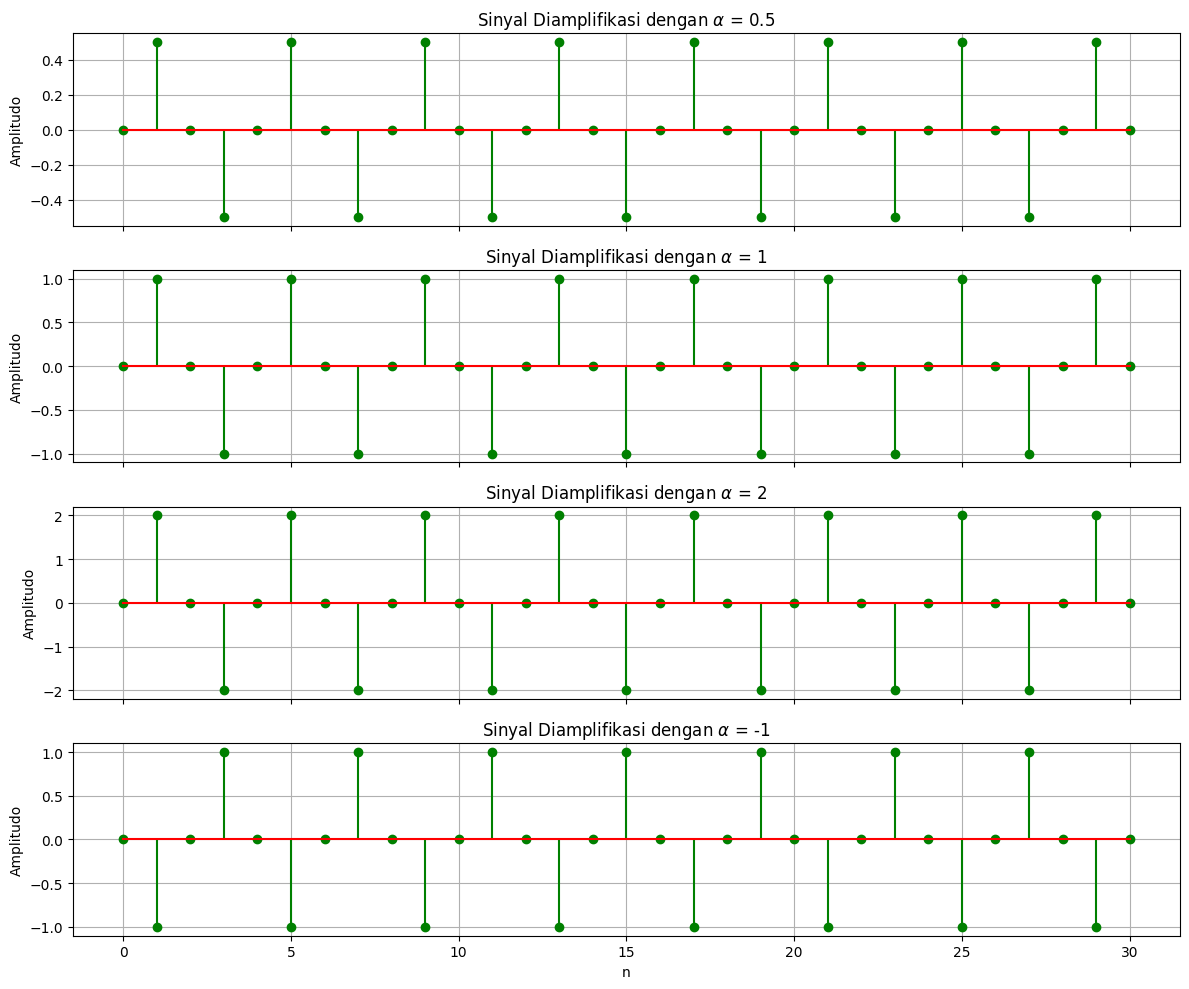

In [4]:
# Operasi Amplifikasi
alpha_vals = [0.5, 1, 2, -1]
y_amp = {alpha: alpha * x1 for alpha in alpha_vals}

# Plot Hasil Amplifikasi
fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

for i, alpha in enumerate(alpha_vals):
    axs[i].stem(n, y_amp[alpha], linefmt='g-', markerfmt='go', basefmt='r-')
    axs[i].set_title(f'Sinyal Diamplifikasi dengan $\\alpha$ = {alpha}')
    axs[i].set_ylabel('Amplitudo')
    axs[i].grid(True)

plt.xlabel('n')
plt.tight_layout()
plt.show()

=== Properti Citra 1 ===
Ukuran Citra (Resolusi): (300, 300) piksel
Tipe Data: uint8
Nilai Piksel Minimum: 0
Nilai Piksel Maksimum: 254



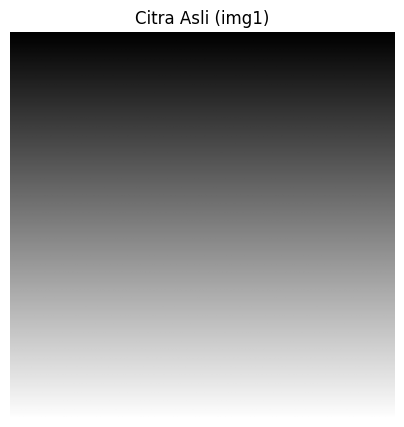

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Membikin citra dummy 1 (Grayscale) berbentuk pola gradasi & kotak untuk eksperimen
# Jika punya foto sendiri, silakan ganti dengan: img1 = cv2.imread('nama_foto.jpg', cv2.IMREAD_GRAYSCALE)
img1 = np.zeros((300, 300), dtype=np.uint8)
for i in range(300):
    img1[i, :] = i * (255 / 300) # Membuat efek gradasi kecerahan

# Properti Citra [cite: 101, 102, 103]
print("=== Properti Citra 1 ===")
print(f"Ukuran Citra (Resolusi): {img1.shape} piksel")
print(f"Tipe Data: {img1.dtype}")
print(f"Nilai Piksel Minimum: {img1.min()}")
print(f"Nilai Piksel Maksimum: {img1.max()}\n")

# Tampilkan Citra Asli [cite: 100]
plt.figure(figsize=(5, 5))
plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
plt.title('Citra Asli (img1)')
plt.axis('off')
plt.show()

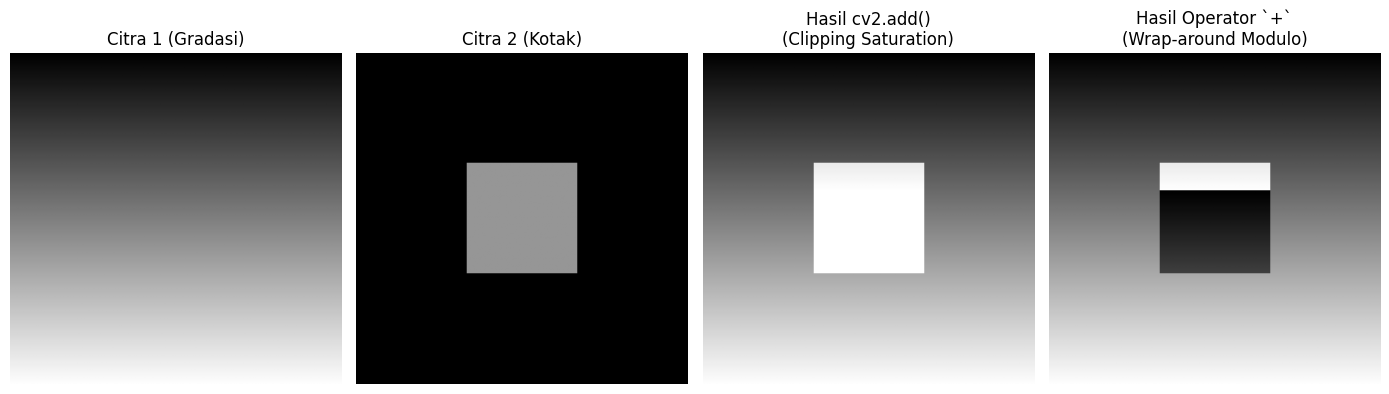

In [6]:
# Membuat citra dummy 2 dengan ukuran yang sama [cite: 107]
# Pola kotak putih di tengah
img2 = np.zeros((300, 300), dtype=np.uint8)
img2[100:200, 100:200] = 150

# Proses Resizing (Contoh simulasi jika ukuran berbeda) [cite: 108, 114]
# Jika citra berbeda ukuran, kamu wajib menyamakannya dengan: img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))
if img1.shape != img2.shape:
    img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

# 1. Penjumlahan dengan Clipping (OpenCV)
img_blend_clip = cv2.add(img1, img2)

# 2. Penjumlahan dengan Wrap-around / Modulo (NumPy)
img_blend_modulo = img1 + img2

# Plot Perbandingan [cite: 110, 111, 112]
plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
plt.title('Citra 1 (Gradasi)')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img2, cmap='gray', vmin=0, vmax=255)
plt.title('Citra 2 (Kotak)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_blend_clip, cmap='gray', vmin=0, vmax=255)
plt.title('Hasil cv2.add()\n(Clipping Saturation)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img_blend_modulo, cmap='gray', vmin=0, vmax=255)
plt.title('Hasil Operator `+`\n(Wrap-around Modulo)')
plt.axis('off')

plt.tight_layout()
plt.show()

<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:29: SyntaxWarning: invalid escape sequence '\D'
<>:34: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:29: SyntaxWarning: invalid escape sequence '\D'
<>:34: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2495/3617814786.py:24: SyntaxWarning: invalid escape sequence '\D'
  plt.title('Geser Kanan\n($\Delta i=30, \Delta j=0$)')
/tmp/ipykernel_2495/3617814786.py:29: SyntaxWarning: invalid escape sequence '\D'
  plt.title('Geser Bawah\n($\Delta i=0, \Delta j=30$)')
/tmp/ipykernel_2495/3617814786.py:34: SyntaxWarning: invalid escape sequence '\D'
  plt.title('Geser Diagonal\n($\Delta i=30, \Delta j=30$)')


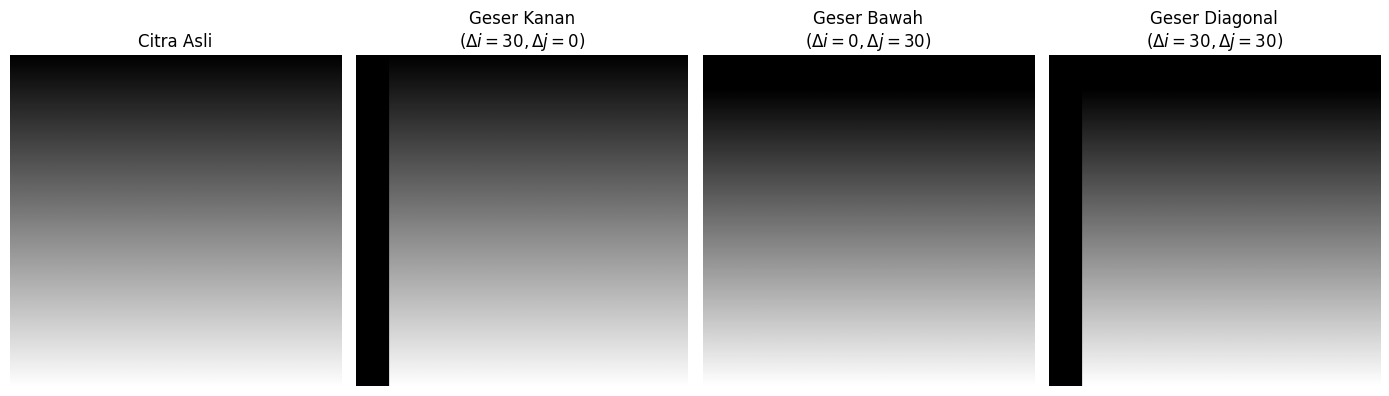

<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:29: SyntaxWarning: invalid escape sequence '\D'
<>:34: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:29: SyntaxWarning: invalid escape sequence '\D'
<>:34: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2495/3617814786.py:24: SyntaxWarning: invalid escape sequence '\D'
  plt.title('Geser Kanan\n($\Delta i=30, \Delta j=0$)')
/tmp/ipykernel_2495/3617814786.py:29: SyntaxWarning: invalid escape sequence '\D'
  plt.title('Geser Bawah\n($\Delta i=0, \Delta j=30$)')
/tmp/ipykernel_2495/3617814786.py:34: SyntaxWarning: invalid escape sequence '\D'
  plt.title('Geser Diagonal\n($\Delta i=30, \Delta j=30$)')


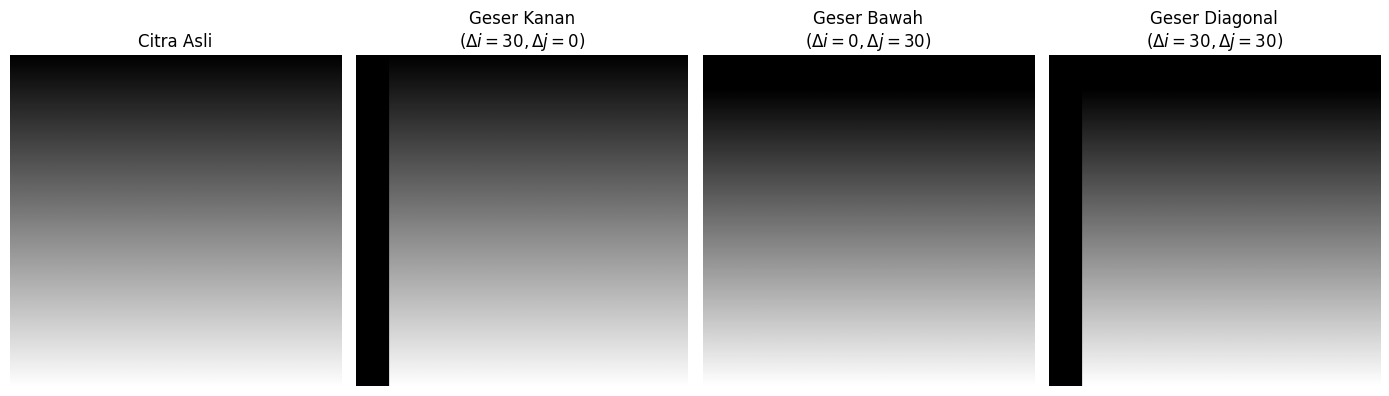

In [8]:
rows, cols = img1.shape

# Fungsi pembantu untuk menggeser citra lewat matriks transformasi OpenCV
def translate_image(img, dx, dy):
    # Matriks transformasi M = [[1, 0, dx], [0, 1, dy]]
    M = np.float32([[1, 0, dx], [0, 1, dy]])
    return cv2.warpAffine(img, M, (cols, rows))

# Jalankan 3 kombinasi pergeseran
shift_1 = translate_image(img1, 30, 0)   # Geser kanan 30 piksel
shift_2 = translate_image(img1, 0, 30)   # Geser bawah 30 piksel
shift_3 = translate_image(img1, 30, 30)  # Geser kanan 30 & bawah 30 piksel

# Plot Perbandingan [cite: 130, 131, 132]
plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(img1, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(shift_1, cmap='gray')
plt.title('Geser Kanan\n($\Delta i=30, \Delta j=0$)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(shift_2, cmap='gray')
plt.title('Geser Bawah\n($\Delta i=0, \Delta j=30$)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(shift_3, cmap='gray')
plt.title('Geser Diagonal\n($\Delta i=30, \Delta j=30$)')
plt.axis('off')

plt.tight_layout()
plt.show()


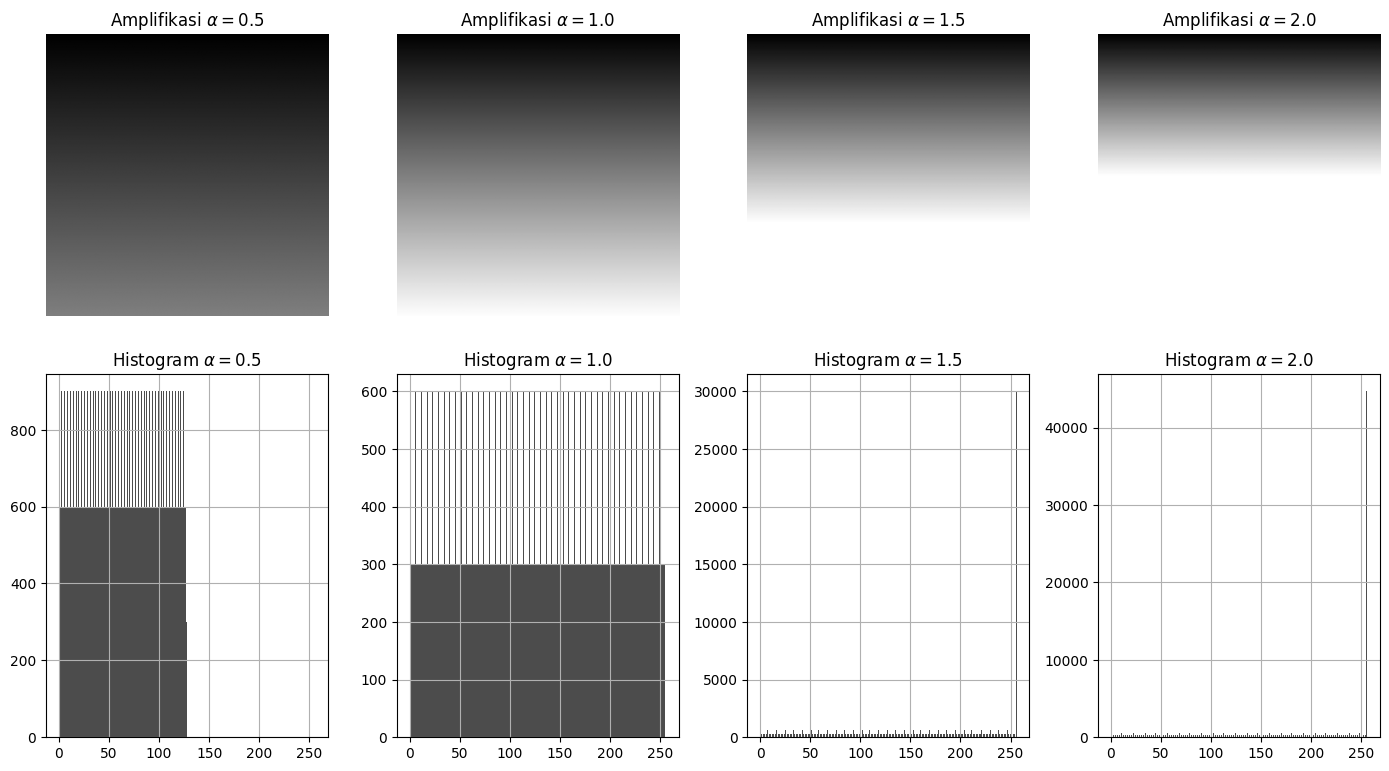

In [9]:
alphas = [0.5, 1.0, 1.5, 2.0]
plt.figure(figsize=(14, 8))

for i, alpha in enumerate(alphas):
    # Amplifikasi dengan clipping agar nilai piksel tidak overflow melewati 255 [cite: 141, 154]
    img_amp = np.clip(img1 * alpha, 0, 255).astype(np.uint8)

    # Tampilkan Citra Hasil Amplifikasi [cite: 147]
    plt.subplot(2, 4, i + 1)
    plt.imshow(img_amp, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Amplifikasi $\\alpha = {alpha}$')
    plt.axis('off')

    # Tampilkan Histogramnya [cite: 148]
    plt.subplot(2, 4, i + 5)
    plt.hist(img_amp.ravel(), bins=256, range=[0, 256], color='black', alpha=0.7)
    plt.title(f'Histogram $\\alpha = {alpha}$')
    plt.grid(True)

plt.tight_layout()
plt.show()